# Diabetes Risk Prediction: Model Reliability Analysis

This notebook reviews the prepared data, locked test-set metrics, probability calibration, threshold trade-offs, explainability, and subgroup diagnostics. The full training workflow is implemented in `scripts/train_models.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RESULTS = ROOT / 'results'
IMAGES = ROOT / 'images'
SAMPLE = ROOT / 'data' / 'sample' / 'diabetes_sample.csv'


## Data Overview

In [2]:
sample = pd.read_csv(SAMPLE)
summary = json.loads((RESULTS / 'data_summary.json').read_text())
summary, sample.shape, sample['Diabetes_binary'].value_counts(normalize=True).sort_index()

({'records': 253680,
  'features': 21,
  'outcome_prevalence': 0.13933301797540207,
  'missing_values': 0,
  'duplicate_rows': 24206,
  'split_sizes': {'train': 152208,
   'validation': 25368,
   'calibration': 38052,
   'test': 38052}},
 (1500, 22),
 Diabetes_binary
 0.0    0.860667
 1.0    0.139333
 Name: proportion, dtype: float64)

The full dataset contains 253,680 records and 21 predictors. The included sample preserves the approximate outcome prevalence but is not used for the reported results.

## Locked Test-Set Model Comparison

In [3]:
metrics = pd.read_csv(RESULTS / 'model_metrics.csv')
display(metrics[['model','roc_auc','pr_auc','brier_score','threshold','sensitivity','specificity','precision']].round(3))

,model,roc_auc,pr_auc,brier_score,threshold,sensitivity,specificity,precision
0,XGBoost,0.828,0.423,0.097,0.14,0.803,0.705,0.306
1,Random Forest,0.824,0.414,0.098,0.13,0.813,0.690,0.298
2,Logistic Regression,0.820,0.391,0.100,0.12,0.817,0.678,0.291
3,1D CNN,0.715,0.286,0.111,0.10,0.790,0.507,0.206


### Discrimination

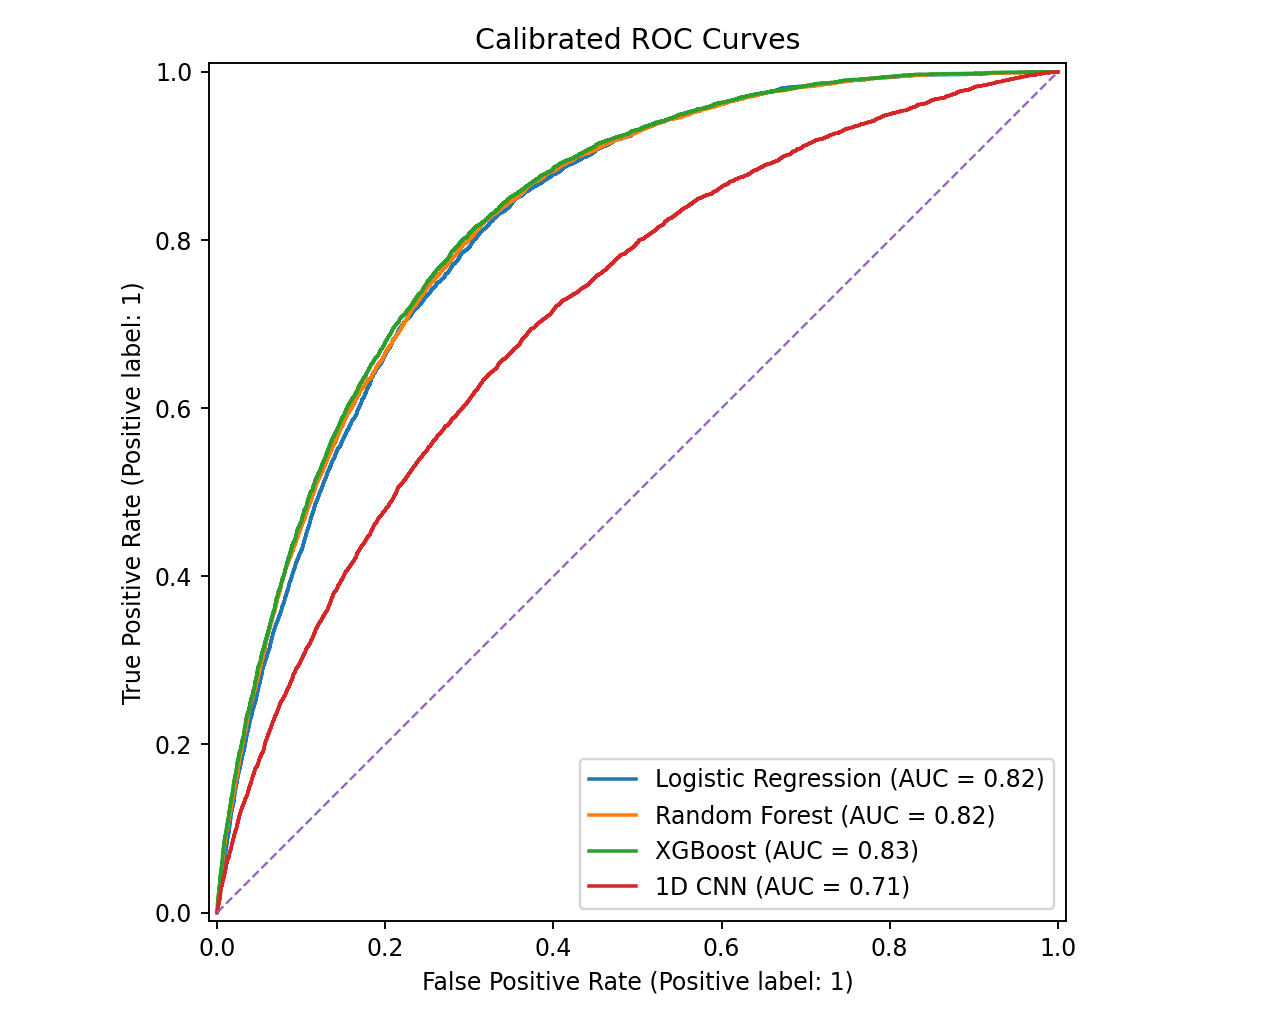

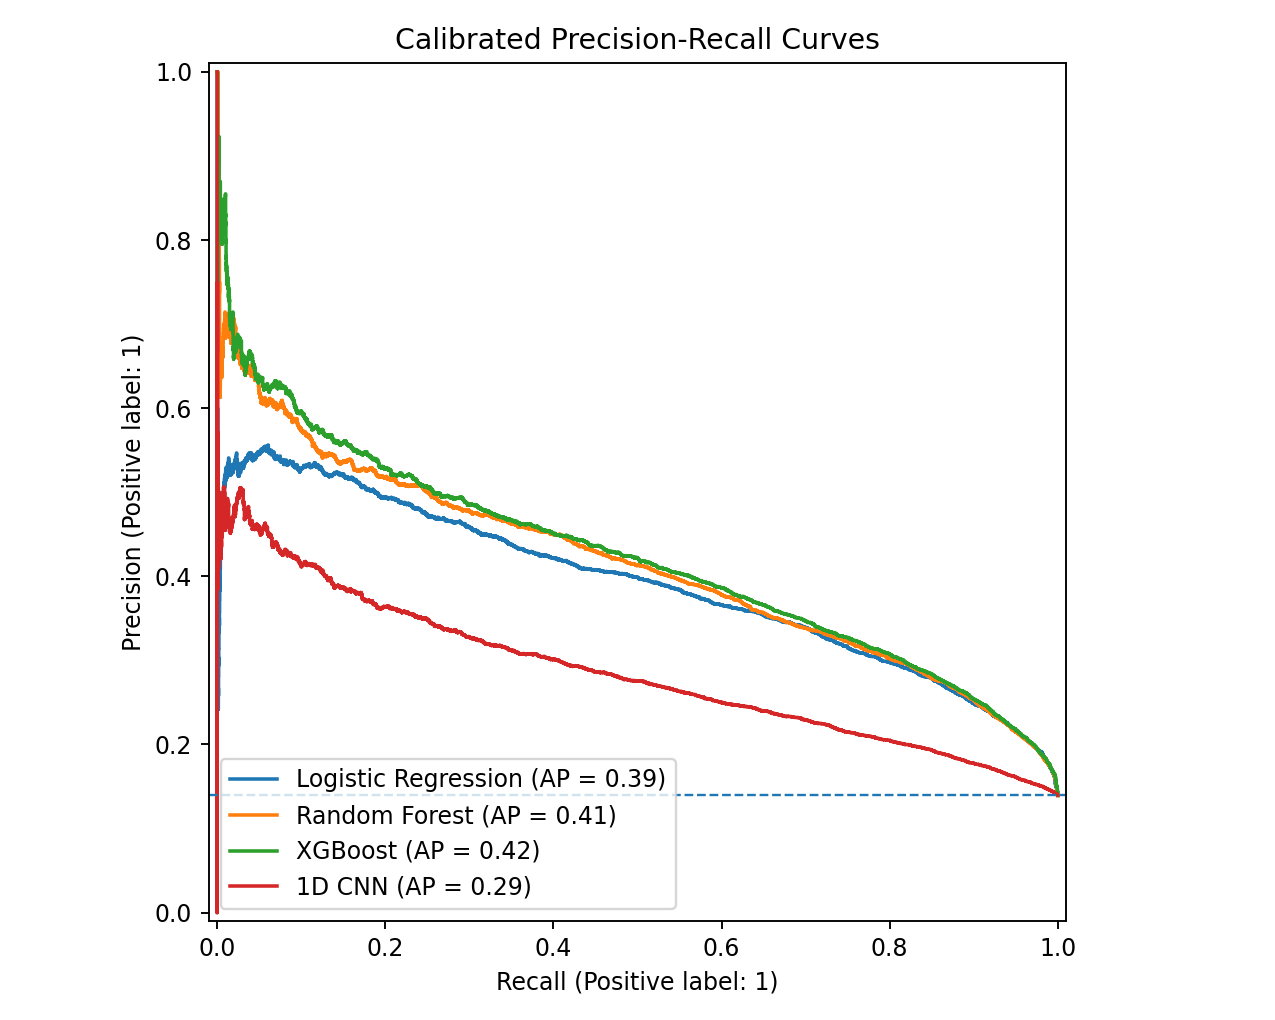

In [4]:
display(Image(filename=str(IMAGES / 'roc_curves.png')))
display(Image(filename=str(IMAGES / 'precision_recall_curves.png')))

### Probability Calibration

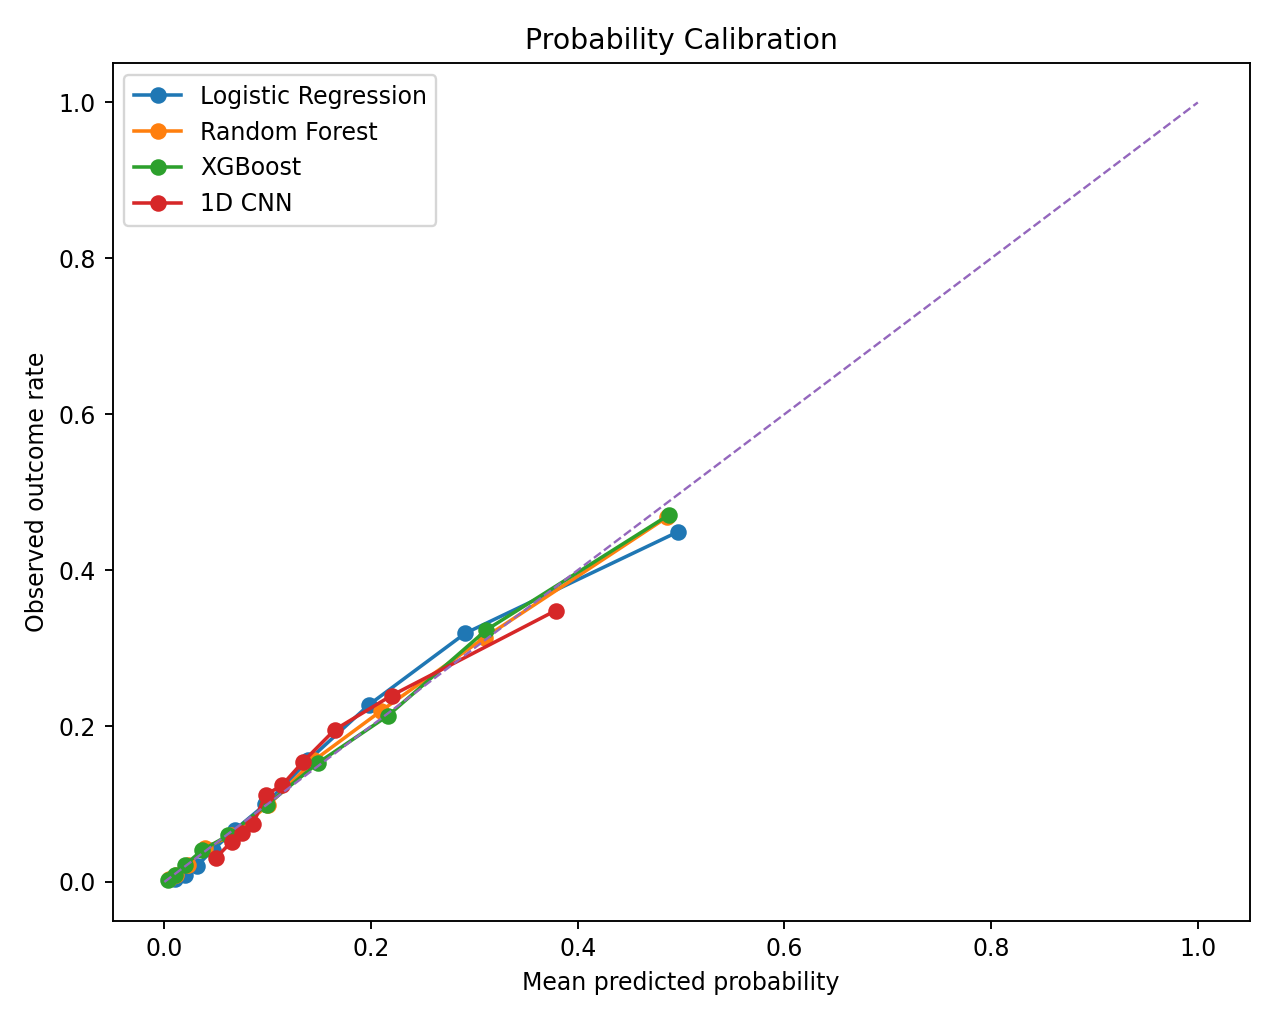

In [5]:
display(Image(filename=str(IMAGES / 'calibration_curves.png')))

## Threshold Selection

In [6]:
thresholds = pd.read_csv(RESULTS / 'threshold_analysis.csv')
xgb = metrics.loc[metrics['model'].eq('XGBoost')].iloc[0]
xgb[['threshold','sensitivity','specificity','precision','negative_predictive_value']].round(3)

threshold                        0.14
sensitivity                  0.802527
specificity                  0.705313
precision                    0.305983
negative_predictive_value    0.956639
Name: 0, dtype: object

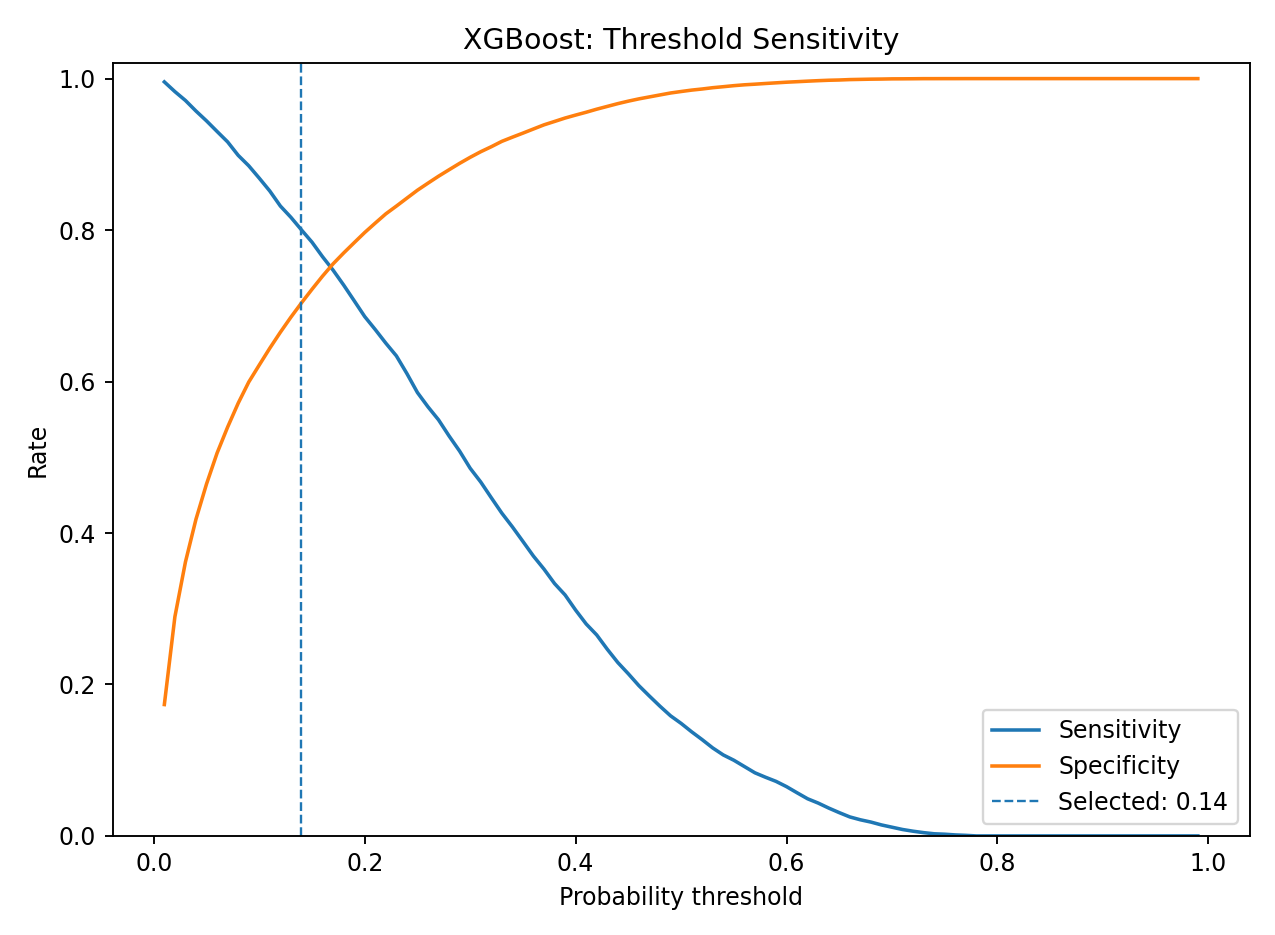

In [7]:
display(Image(filename=str(IMAGES / 'threshold_analysis_xgboost.png')))

## Explainability

In [8]:
xgb_importance = pd.read_csv(RESULTS / 'xgboost_shap_importance.csv')
cnn_importance = pd.read_csv(RESULTS / 'cnn_integrated_gradients.csv')
display(xgb_importance.head(10).round(4))
display(cnn_importance.head(10).round(4))

,feature,importance
0,GenHlth,0.6087
1,HighBP,0.4800
2,BMI,0.4172
3,Age,0.4156
4,HighChol,0.2904
5,Sex,0.1266
6,Income,0.1264
7,HvyAlcoholConsump,0.0662
8,MentHlth,0.0662
9,HeartDiseaseorAttack,0.0628


,feature,importance
0,Smoker,0.0850
1,Sex,0.0812
2,HighChol,0.0775
3,Fruits,0.0756
4,Age,0.0640
5,PhysActivity,0.0622
6,GenHlth,0.0607
7,DiffWalk,0.0602
8,BMI,0.0599
9,HeartDiseaseorAttack,0.0590


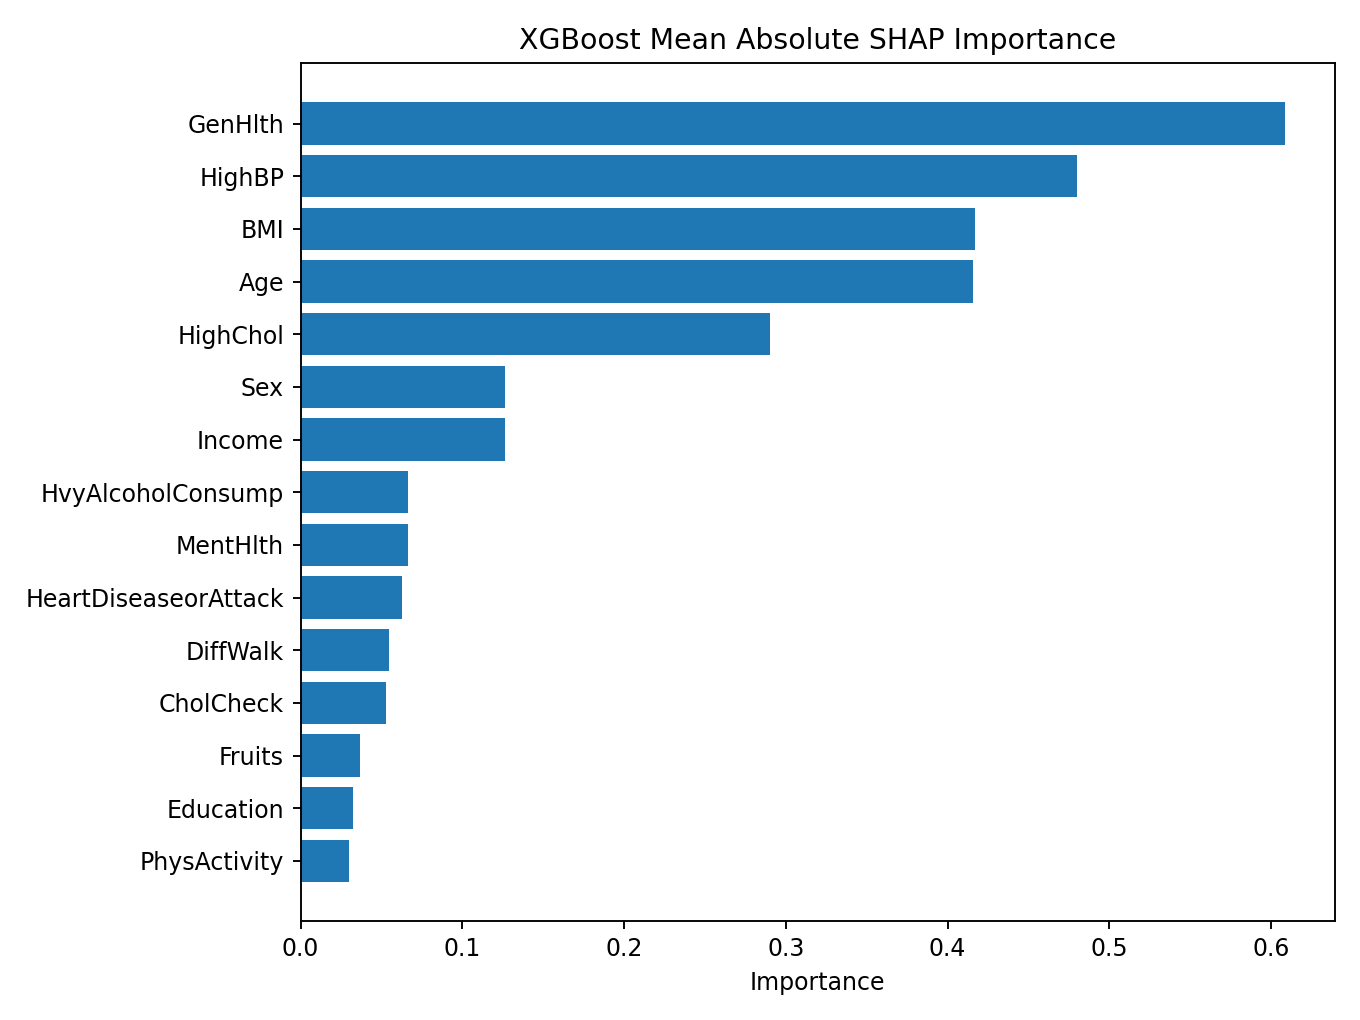

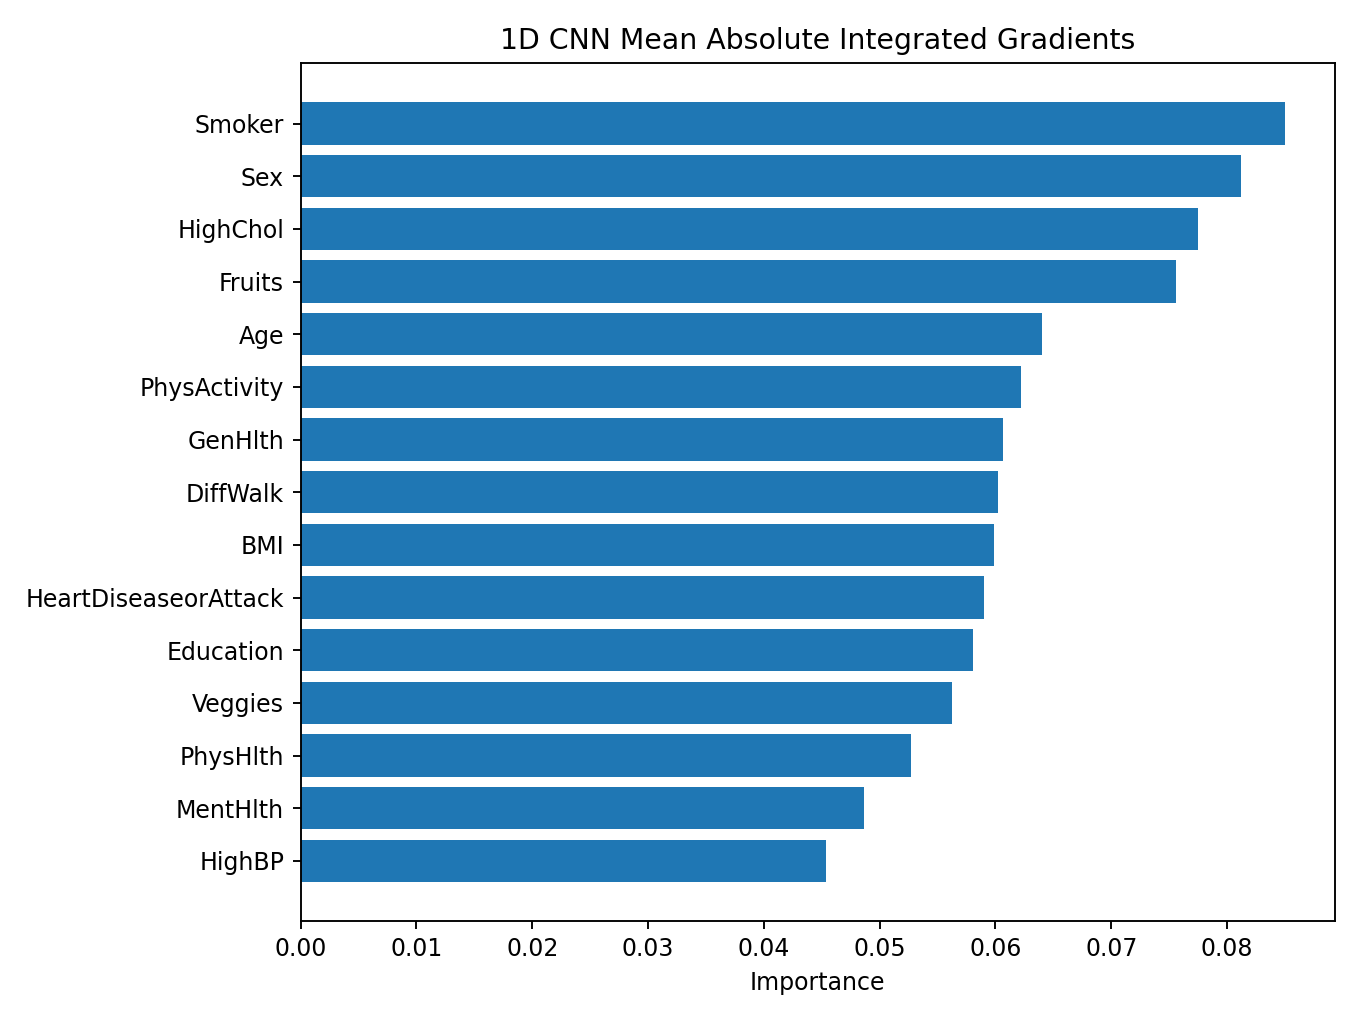

In [9]:
display(Image(filename=str(IMAGES / 'xgboost_shap_importance.png')))
display(Image(filename=str(IMAGES / 'cnn_integrated_gradients.png')))

SHAP and Integrated Gradients describe fitted model behaviour. They do not establish causal or clinical importance.

## CNN Training

,epoch,train_loss,validation_loss,validation_pr_auc,learning_rate
0,1.0,1.1841,1.1726,0.2893,0.002
1,2.0,1.1610,1.1455,0.2923,0.002
2,3.0,1.1330,1.1169,0.2941,0.002
3,4.0,1.1045,1.0893,0.2959,0.002


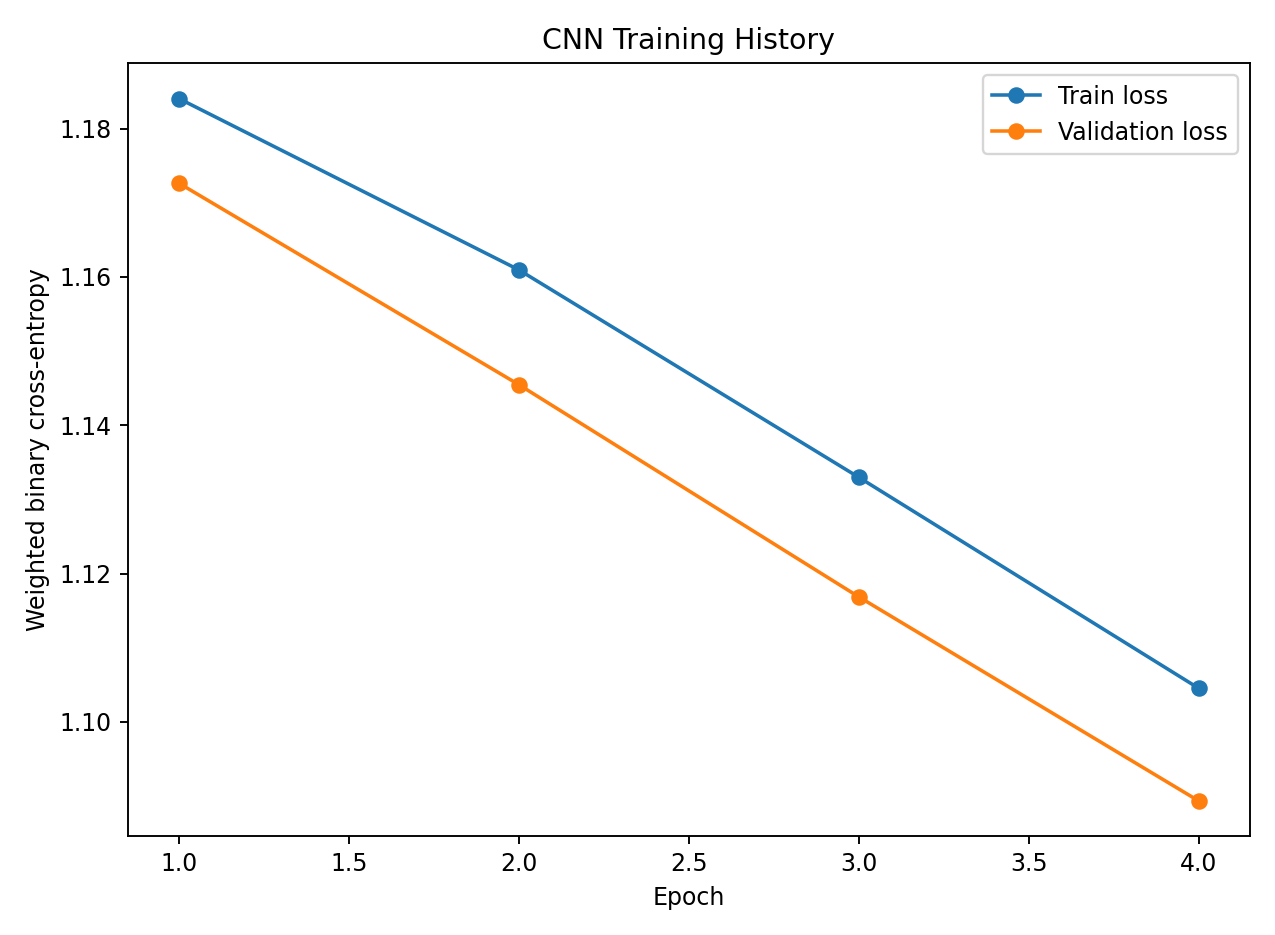

In [10]:
cnn_history = pd.read_csv(RESULTS / 'cnn_training_history.csv')
display(cnn_history.round(4))
display(Image(filename=str(IMAGES / 'cnn_training_history.png')))

The compact 1D CNN is an experimental deep-learning benchmark. It underperforms the tree models, which is consistent with the limited local structure of the tabular feature sequence.

## Subgroup Diagnostics

,model,subgroup_variable,subgroup,n,prevalence,mean_predicted_risk,calibration_gap,roc_auc,pr_auc,sensitivity,specificity
0,XGBoost,Sex_group,Female,21317,0.128,0.130,0.002,0.839,0.419,0.792,0.735
1,XGBoost,Sex_group,Male,16735,0.154,0.152,-0.001,0.813,0.427,0.814,0.666
2,XGBoost,Age_group,18-34,5834,0.032,0.030,-0.003,0.852,0.290,0.386,0.970
3,XGBoost,Age_group,35-49,9224,0.093,0.094,0.001,0.842,0.380,0.676,0.822
4,XGBoost,Age_group,50-64,14352,0.173,0.172,-0.001,0.811,0.457,0.841,0.636
5,XGBoost,Age_group,65+,8642,0.205,0.209,0.004,0.739,0.403,0.855,0.466
6,XGBoost,Income_group,High,20141,0.094,0.094,0.000,0.834,0.356,0.681,0.809
7,XGBoost,Income_group,Low,3182,0.255,0.245,-0.010,0.770,0.493,0.895,0.477
8,XGBoost,Income_group,Lower-middle,5407,0.210,0.210,0.001,0.791,0.474,0.897,0.521
9,XGBoost,Income_group,Upper-middle,9322,0.157,0.161,0.004,0.806,0.415,0.835,0.634


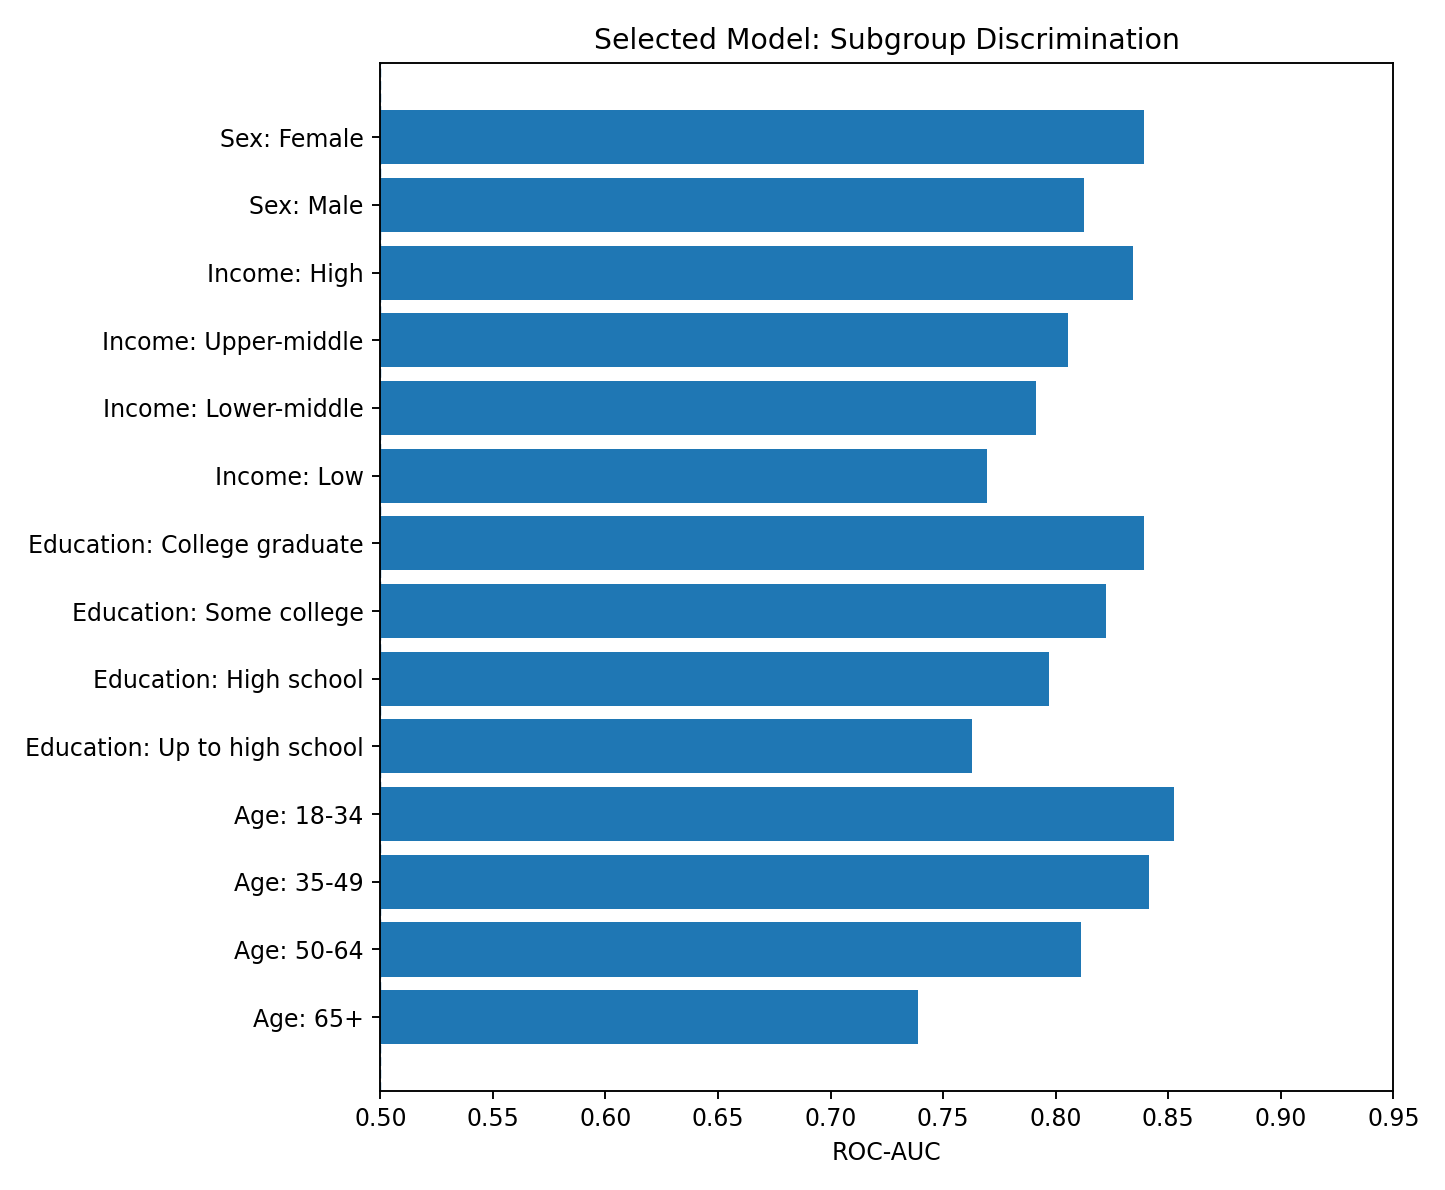

In [11]:
subgroups = pd.read_csv(RESULTS / 'subgroup_metrics.csv')
display(subgroups.round(3))
display(Image(filename=str(IMAGES / 'subgroup_roc_auc.png')))

A common threshold produces different operating characteristics across groups. These are descriptive monitoring results, not a complete fairness conclusion.

## Conclusion

XGBoost provides the strongest PR-AUC and Brier score in the locked test set. Random Forest and Logistic Regression remain competitive baselines. The CNN demonstrates an end-to-end PyTorch workflow but does not improve predictive performance. The project therefore illustrates both deep-learning implementation and evidence-based model selection.